<a href="https://colab.research.google.com/github/raven-in-space/data-science-cohort-20/blob/main/Project-2/Predicting_Housing_Prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicting Housing Prices Using Linear Regression and RMSPE
* **Date <u>Started</u>:** `4/10/2026`
* **Author:** Raven Otero-Symphony
* **Program:** CNM Ingenuity [Data Science Bootcamp]()

**DISCLAIMER:** Claude AI was used to develop select code due to time constraints. Code that was informed by Claude AI feedback is shown with a 🤖 icon.

# Problem Definition

The Accessor's Office has provided data on individual residential properties sold from 2006 to 2010. This project aims to *reliably* predict house sales prices through feature scaling, regularization, and minimixing the **Root Mean Square *Percentage* Error (RMSPE)** in a predictive regression model. Secondarily, we aim to find the most reliable model with the *least* amount of variables possible to predict housing prices.

# Data Collection

We are using Python data cleaning and regression methods, including `sklearn`, to fit and evaluate our predictive model.

**Data Sources:**
1. [Source Data](https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv) - collected from AWS S3.
2. [Data Dictionary](https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf) - a brief description of the data and its and features.

# Data Cleaning

## Load

In [59]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

## IDE

In [60]:
orig_housing = pd.read_csv("https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Data/Housing.Data.csv")
orig_housing.shape

(2637, 81)

In [61]:
orig_housing.head(5)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,905101070,20,RL,62.0,14299,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,7,2007,WD,Normal,115400
1,905101330,90,RL,72.0,10791,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,Shed,500,10,2006,WD,Normal,90000
2,903454090,50,RM,50.0,9000,Pave,NaN,Reg,Bnk,AllPub,...,0,NaN,NaN,NaN,0,12,2007,WD,Normal,141000
3,533244030,60,FV,68.0,7379,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,254000
4,909252020,70,RL,60.0,7200,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,4,2009,WD,Normal,155000


In [62]:
orig_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 81 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PID              2637 non-null   int64  
 1   MS SubClass      2637 non-null   int64  
 2   MS Zoning        2637 non-null   object 
 3   Lot Frontage     2188 non-null   float64
 4   Lot Area         2637 non-null   int64  
 5   Street           2637 non-null   object 
 6   Alley            180 non-null    object 
 7   Lot Shape        2637 non-null   object 
 8   Land Contour     2637 non-null   object 
 9   Utilities        2637 non-null   object 
 10  Lot Config       2637 non-null   object 
 11  Land Slope       2637 non-null   object 
 12  Neighborhood     2637 non-null   object 
 13  Condition 1      2637 non-null   object 
 14  Condition 2      2637 non-null   object 
 15  Bldg Type        2637 non-null   object 
 16  House Style      2637 non-null   object 
 17  Overall Qual  

In [63]:
# checking "NA" values from data dictionary... these are getting picked up as NaN
orig_housing['Garage Qual'].unique()

array(['TA', 'Fa', nan, 'Gd', 'Ex', 'Po'], dtype=object)

**Initial Observations:**
* According to the [data dictionary](https://ddc-datascience.s3.amazonaws.com/Projects/Project.2-Housing/Housing%20-%20Data%20Documentation.pdf), there should be **2,930 observations (rows)** and **82 variables (features)**. What we find instead is that there are **2,637 rows** and **81 columns**. That's a difference of **293 rows** and **1 column**. I wonder which feature has the most missing rows, and why?
* The `MS Subclass` feature is being picked up as an integer rather than the nominal variable it actually is. Type conversions will be necessary for some features!
* The classification of nominal versus ordinal variables is interesting within the dictionary. For example, `Lot Shape` is considered ordinal but `Land Contour` is considered nominal.
* The `Sawyer` versus `Sawyer West` naming in the `Neighborhood` feature is *hopefully* labeled correctly in the actual data... hopefully (re-classifying would require a judgement call since I can't actually reach out to the PoC).
* I might combine or drop `Condition 1` with `Condition 2`, `Exterior 1` with `Exterior 2`, `Exter Qual` with `Exter Cond`, `Bsmt Qual` with `Bsmt Cond`, depending on correlation strength and model relevancy, since the labels within these features repeat themselves.
* As an aside, it would be interesting to look at the `Overall Qual` and `Overall Cond` features (since those seem self-reported) against other features of the house. Did the surveyor assume quality in a consistent fashion across houses? Or did they hold some biases?
* `SalePrice` is the target variable and has no missing rows.
* Some nominal variables contain the value `NA` to signify the *lack* of the feature in question. However, this is being picked up as `NULL` in Python, therefore when reclassifying, these must be carefully treated. These include:
  * `Alley`
  * `Bsmt Cond`
  * `Bsmt Exposure`
  * `BsmtFin Type 1`
  * `BsmtFin Type 2`
  * `FireplaceQu`
  * `Garage Type`
  * `Garage Finish`
  * `Garage Qual`
  * `Garage Cond`
  * `Pool QC`
  * `Fence`

### Missing Data

In [64]:
# create a copy
main_housing = orig_housing.copy()

In [65]:
# Create a summary table of missing values
null_summary = pd.DataFrame({
    'Total NaNs': ( main_housing.isna().sum() ),
    'NaN Percentage': ( (main_housing.isna().sum() / len(main_housing)) * 100 )
}).sort_values(by='Total NaNs', ascending=False)

# create a filter for 50% missing data, a standard to "drop" features if met
missing_50 = null_summary[null_summary['NaN Percentage'] > 50]

# return results
##null_summary
missing_50

,Total NaNs,NaN Percentage
Pool QC,2626,99.582859
Misc Feature,2541,96.359499
Alley,2457,93.174061
Fence,2109,79.977247
Mas Vnr Type,1607,60.940463


**Missing Data Summary:**
* **5 features** have **over 50%** of missing data. Although 48% of `Fireplace Qu` is missing (see `null_summary`), I'm going to drop that feature as well because it is so close to 50% in context of the rest of the data.
* **10 features** are missing **2-5%** of data and **1 feature** is missing **17%** of data. These can be imputed, although my hunch is that some of the features will be highly correlated amongst themselves (do data scientists work off of hunches? I do).
* **9 features** are missing less than **1%** of data. Again, this can be imputed if necessary.
* The remaining **57 features** aren't missing any data, including the target variable.

In [66]:
# store original columns
original_cols = set(main_housing.columns)

# drop features at cutoff - cell stops here so I can adjust the cutoff #
cutoff = ( len(main_housing) * 0.6 )
main_housing = main_housing.dropna(axis = 1, thresh=cutoff)

In [67]:
# return dropped columns
dropped_cols = original_cols - set(main_housing.columns)
print(f'The following columns are dropped for missing over 50% of data: {dropped_cols}')

The following columns are dropped for missing over 50% of data: {'Pool QC', 'Alley', 'Mas Vnr Type', 'Fence', 'Misc Feature', 'Fireplace Qu'}


In [68]:
# total NaNs across all rows
print(f'Total values still missing: {main_housing.isnull().sum().sum()}')
print(f'Shape of data: {main_housing.shape}')

Total values still missing: 1584
Shape of data: (2637, 75)


* The [`set` method](https://www.geeksforgeeks.org/pandas/create-a-set-from-a-series-in-pandas/) is used to check which columns are not in the original data after being removed for meeting the `cutoff`.
* Strange how `Condition 2` appears more than `Condition 1` when the data dictionary states that `Condition 2` exists only if more than one characteristic from `Condition 1` exists...

## EDA

* In order to fit a linear regression with a `numeric` predictor, this section analyzies the dependent features in 4 sections:
  1) Categorical - Nominal Data
  2) Categorical - Ordinal Data
  3) Numeric - `int` Data
  4) Numeric - `float64` Data
* `categorical` data will be converted into `numeric` values to fit the model.
  * If a `categorical` variable has **2 outputs**, we opt for **binary coercion** to avoid multicollinearity.
  * If a `categorical` variable has **more than 2 outputs**, we opt for **one-hot encoding**.
* `numeric` data may be imputed, given time constraints, by using either the `mean` or `median`.

In [69]:
# create filters for relevant summary stats
stats_cat = main_housing.select_dtypes(include='object') # "cat" stands for "categorical"
stats_num = main_housing.select_dtypes(include='number') # "num" stands for "numerical"

### **Section 1:** Categorical Data

* First, let's **convert those `NA` values** accidentally getting picked up as `NaN` into `None` for clarity.

In [70]:
# create list
false_nans = ['Bsmt Cond', 'Bsmt Exposure', 'BsmtFin Type 1', 'BsmtFin Type 2', 'Garage Type', 'Garage Finish', 'Garage Qual', 'Garage Cond']

# replace NaN with "NA" in list for cat vars
for col in false_nans:
  main_housing[col] = ["None" if pd.isna(val) else val for val in main_housing[col]]

* Now, let's **visualize the trends** in the categorical data to inform next steps:

In [81]:
# visualize the categorical features
cat_summary = stats_cat.describe().transpose().sort_values(by='unique', ascending=True)
cat_summary

,count,unique,top,freq
Street,2637,2,Pave,2625
Central Air,2637,2,Y,2460
Garage Finish,2490,3,Unf,1106
Utilities,2637,3,AllPub,2634
Land Slope,2637,3,Gtl,2511
Paved Drive,2637,3,Y,2395
Lot Shape,2637,4,Reg,1662
Land Contour,2637,4,Lvl,2365
Exter Qual,2637,4,TA,1614
Bsmt Exposure,2561,4,No,1722


In [82]:
# how many categorical vars can be one-hot encoded?
unique_ohe = cat_summary[cat_summary['unique'] > 2]
unique_ohe.shape

(35, 4)

In [83]:
# well isn't this a pain...
stats_cat['Paved Drive'].unique()

array(['N', 'Y', 'P'], dtype=object)

**Categorical Data Observations:**
* Two features (`Street` and `Central Air`) can be converted to `binary` to avoid multicollinearity, since two values are always the inverse of each other.
* After checking the data dictionary, `Paved Drive` does need the third value...
* There are **35 features** that could be one-hot encoded.
* `pandas` doesn't distinguish between **nominal** versus **ordinal** data, but the data dictionary *does.*
  * According to [Geeks for Geeks](https://www.geeksforgeeks.org/machine-learning/one-hot-encoding-vs-label-encoding/) (one of my favorite data science websites), one-hot encoding should be used for nominal data when the number of unique categories is relatively small.
  * Ordinal data requires much more of a judgement call since it assumes equal distance between data points, which may not always be true. (e.g., Is the difference between "Poor" and "Good" the same as "Great" and "Excellent"?)

#### (1a) Ordinal Data

In [84]:
# checking to ensure ordinal columns exist in data
stats_cat_cols = set(stats_cat.columns)

# refer to data dictionary
ordinal_cols = [
    'Lot Shape',
    'Utilities',
    'Land Slope',
    'Exter Qual',
    'Exter Cond',
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Electrical',
    'Functional',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Paved Drive'
]

# 🎈do all ordinal cols exist
if set(ordinal_cols) in stats_cat_cols:
  print("All columns accounted for.")
else:
  print(f"The following columns are missing: {set(ordinal_cols) - stats_cat_cols}")

The following columns are missing: set()


In [85]:
# 🤖 This code cell was developed with the help of Claude AI
# Visualize dist of ordinal data
ordinal_fig = make_subplots(rows=4, cols=4, subplot_titles=ordinal_cols)

n = 0
for i in range(1, 5):
    for j in range(1, 5):
        ordinal_fig.add_trace(
            go.Histogram(
                x=main_housing[ordinal_cols[n]],
                name=ordinal_cols[n],
                showlegend=False,
                marker_color='#636EFA'
            ),
            row=i, col=j
        )
        n += 1

ordinal_fig.update_layout(
    height=800,
    width=1200,
    title_text="Ordinal Column Distributions"
)

ordinal_fig.show()

**Ordinal Features Observations:**
* There are **16** ordinal features.
* Many of these features are heavily left-skewed, making it likely that, after one-hot encoding, many values will be dropped due to lack of data.

In [86]:
# opting for pd.Categorical() since LabelEncoder uses alphabetical assignment, not order

# create dictionary
ordinal_orders = {
    'Lot Shape':        ['Reg', 'IR1', 'IR2', 'IR3'],
    'Utilities':        ['ELO', 'NoSeWa', 'NoSewr', 'AllPub'],
    'Land Slope':       ['Sev', 'Mod', 'Gtl'],
    'Exter Qual':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Exter Cond':       ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Qual':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Cond':        ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Bsmt Exposure':    ['None', 'No', 'Mn', 'Av', 'Gd'],
    'BsmtFin Type 1':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'BsmtFin Type 2':   ['None', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    'Electrical':       ['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    'Functional':       ['Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    'Garage Finish':    ['None', 'Unf', 'RFn', 'Fin'],
    'Garage Qual':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Garage Cond':      ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'Paved Drive':      ['N', 'P', 'Y']
}

# encode via loop
for col, order in ordinal_orders.items():
  main_housing[col] = pd.Categorical(main_housing[col],
                                     categories=order,
                                     ordered=True).codes

# validate
for col, order in ordinal_orders.items():
  print(f"\n{col}:")
  for i, val in enumerate(order):
    print(f" {i} = {val}")


Lot Shape:
 0 = Reg
 1 = IR1
 2 = IR2
 3 = IR3

Utilities:
 0 = ELO
 1 = NoSeWa
 2 = NoSewr
 3 = AllPub

Land Slope:
 0 = Sev
 1 = Mod
 2 = Gtl

Exter Qual:
 0 = Po
 1 = Fa
 2 = TA
 3 = Gd
 4 = Ex

Exter Cond:
 0 = Po
 1 = Fa
 2 = TA
 3 = Gd
 4 = Ex

Bsmt Qual:
 0 = None
 1 = Po
 2 = Fa
 3 = TA
 4 = Gd
 5 = Ex

Bsmt Cond:
 0 = None
 1 = Po
 2 = Fa
 3 = TA
 4 = Gd
 5 = Ex

Bsmt Exposure:
 0 = None
 1 = No
 2 = Mn
 3 = Av
 4 = Gd

BsmtFin Type 1:
 0 = None
 1 = Unf
 2 = LwQ
 3 = Rec
 4 = BLQ
 5 = ALQ
 6 = GLQ

BsmtFin Type 2:
 0 = None
 1 = Unf
 2 = LwQ
 3 = Rec
 4 = BLQ
 5 = ALQ
 6 = GLQ

Electrical:
 0 = Mix
 1 = FuseP
 2 = FuseF
 3 = FuseA
 4 = SBrkr

Functional:
 0 = Sal
 1 = Sev
 2 = Maj2
 3 = Maj1
 4 = Mod
 5 = Min2
 6 = Min1
 7 = Typ

Garage Finish:
 0 = None
 1 = Unf
 2 = RFn
 3 = Fin

Garage Qual:
 0 = None
 1 = Po
 2 = Fa
 3 = TA
 4 = Gd
 5 = Ex

Garage Cond:
 0 = None
 1 = Po
 2 = Fa
 3 = TA
 4 = Gd
 5 = Ex

Paved Drive:
 0 = N
 1 = P
 2 = Y


In [103]:
ordinal_cols_with_target = [
    'SalePrice',
    'Lot Shape',
    'Utilities',
    'Land Slope',
    'Exter Qual',
    'Exter Cond',
    'Bsmt Qual',
    'Bsmt Cond',
    'Bsmt Exposure',
    'BsmtFin Type 1',
    'BsmtFin Type 2',
    'Electrical',
    'Functional',
    'Garage Finish',
    'Garage Qual',
    'Garage Cond',
    'Paved Drive'
]
ordinal_df = main_housing[ordinal_cols_with_target]
ordinal_df

,SalePrice,Lot Shape,Utilities,Land Slope,Exter Qual,Exter Cond,Bsmt Qual,Bsmt Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Electrical,Functional,Garage Finish,Garage Qual,Garage Cond,Paved Drive
0,115400,0,3,2,2,2,3,3,1,3,2,4,7,1,3,3,0
1,90000,0,3,2,2,2,-1,0,0,0,0,4,7,1,3,3,2
2,141000,0,3,2,2,3,3,3,1,1,1,4,7,1,3,3,1
3,254000,1,3,2,3,2,4,3,1,6,1,4,7,2,3,3,2
4,155000,0,3,2,3,3,4,4,1,5,4,4,7,2,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,114500,0,3,2,2,2,3,3,1,1,1,4,7,1,3,3,2
2633,162000,1,3,2,3,2,4,3,1,6,5,4,7,1,3,3,2
2634,211500,1,3,2,3,2,4,3,4,6,1,4,7,3,3,3,2
2635,165000,0,3,2,2,2,4,3,1,1,1,4,7,2,3,3,2


In [110]:
# correlation plot
ordinal_corr = ordinal_df.corr().round(2)
ordinal_corr_fig = px.imshow(ordinal_corr, color_continuous_scale='ice', title="Ordinal Correlation Matrix with Target Variable")
ordinal_corr_fig.show()

In [147]:
# from https://stackoverflow.com/questions/44889508/remove-highly-correlated-columns-from-a-pandas-dataframe
ordinal_50 = ~(ordinal_corr.mask(np.eye(len(ordinal_corr), dtype=bool)).abs() > 0.5).any()
ordinal_keep = ordinal_corr.loc[ordinal_50, ordinal_50]
ordinal_keep

,Lot Shape,Utilities,Land Slope,Exter Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Electrical,Functional,Paved Drive
Lot Shape,1.00,-0.02,-0.10,-0.01,0.20,0.14,0.04,0.11,0.04,0.14
Utilities,-0.02,1.00,-0.01,0.03,0.03,0.00,-0.02,0.07,0.03,0.02
Land Slope,-0.10,-0.01,1.00,0.02,-0.24,-0.05,-0.06,-0.00,0.08,0.00
Exter Cond,-0.01,0.03,0.02,1.00,0.01,0.07,0.10,0.14,0.10,0.08
Bsmt Exposure,0.20,0.03,-0.24,0.01,1.00,0.36,0.15,0.14,0.08,0.14
BsmtFin Type 1,0.14,0.00,-0.05,0.07,0.36,1.00,0.10,0.20,0.13,0.28
BsmtFin Type 2,0.04,-0.02,-0.06,0.10,0.15,0.10,1.00,0.07,-0.02,0.09
Electrical,0.11,0.07,-0.00,0.14,0.14,0.20,0.07,1.00,0.08,0.26
Functional,0.04,0.03,0.08,0.10,0.08,0.13,-0.02,0.08,1.00,0.13
Paved Drive,0.14,0.02,0.00,0.08,0.14,0.28,0.09,0.26,0.13,1.00


In [148]:
ordinal_keep_cols = ordinal_keep.columns
ordinal_all = main_housing[ordinal_keep_cols]
ordinal_all

,Lot Shape,Utilities,Land Slope,Exter Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Electrical,Functional,Paved Drive
0,0,3,2,2,1,3,2,4,7,0
1,0,3,2,2,0,0,0,4,7,2
2,0,3,2,3,1,1,1,4,7,1
3,1,3,2,2,1,6,1,4,7,2
4,0,3,2,3,1,5,4,4,7,2
...,...,...,...,...,...,...,...,...,...,...
2632,0,3,2,2,1,1,1,4,7,2
2633,1,3,2,2,1,6,5,4,7,2
2634,1,3,2,2,4,6,1,4,7,2
2635,0,3,2,2,1,1,1,4,7,2


#### (1b) Nominal Data

In [111]:
# now checking nominal...
nominal_cols = [
    'PID',
    'MS SubClass',
    'MS Zoning',
    'Street',
    'Land Contour',
    'Lot Config',
    'Neighborhood',
    'Condition 1',
    'Condition 2',
    'Bldg Type',
    'House Style',
    'Roof Style',
    'Roof Matl',
    'Exterior 1st', # incorrectly named in dictionary
    'Exterior 2nd', # incorrectly named in dictionary
    'Foundation',
    'Heating',
    'Central Air',
    'Garage Type',
    'Sale Type',
    'Sale Condition'
]

if set(nominal_cols) in stats_cat_cols:
  print("All columns accounted for.")
else:
  print(f"The following columns are missing: {set(nominal_cols) - stats_cat_cols}")

The following columns are missing: {'MS SubClass', 'PID'}


* `PID` is an identifier column and will be dropped.
* `MS SubClass` is being picked up as an `int`, not the categorical variable that it actually is.

In [112]:
# checkpoint copy
no_eda_housing = main_housing.copy()

In [113]:
# drop PID
main_housing = main_housing.drop(axis=1, columns='PID')

# create binary values from Street and Central Air
main_housing['Street'] = main_housing['Street'].replace({
    'Pave': '1',
    'Gravl': '0'
}).astype(bool) # using .astype because there are no NaNs

main_housing['Central Air'] = main_housing['Central Air'].replace({
    'Y': '1',
    'N': '0'
}).astype(bool)

print(f'Street is now type: {main_housing['Street'].dtype}')
print(f'Central Air is now type: {main_housing['Central Air'].dtype}')

KeyError: "['PID'] not found in axis"

In [114]:
# new list
nominal_cols_new = [
    #'MS SubClass',
    'MS Zoning',
    'Street',
    'Land Contour',
    'Lot Config',
    'Neighborhood',
    'Condition 1',
    'Condition 2',
    'Bldg Type',
    'House Style',
    'Roof Style',
    'Roof Matl',
    'Exterior 1st', # incorrectly named in dictionary
    'Exterior 2nd', # incorrectly named in dictionary
    'Foundation',
    'Heating',
    'Central Air',
    'Garage Type',
    'Sale Type',
    'Sale Condition'
]

# one-hot encode
for col in nominal_cols_new:
    main_housing = pd.get_dummies(main_housing, columns=[col], prefix=col, prefix_sep="_", drop_first=True)

# verify
main_housing.head(5)

# print cols
##test = main_housing.columns.tolist()
##print(test)

KeyError: "None of [Index(['MS Zoning'], dtype='object')] are in the [columns]"

In [185]:
nominal_cols_with_target = [
  'SalePrice', 'MS SubClass_30', 'MS SubClass_40', 'MS SubClass_45', 'MS SubClass_50', 'MS SubClass_60', 'MS SubClass_70', 'MS SubClass_75', 'MS SubClass_80', 'MS SubClass_85', 'MS SubClass_90', 'MS SubClass_120', 'MS SubClass_150', 'MS SubClass_160', 'MS SubClass_180', 'MS SubClass_190', 'MS Zoning_C (all)', 'MS Zoning_FV', 'MS Zoning_I (all)', 'MS Zoning_RH', 'MS Zoning_RL', 'MS Zoning_RM', 'Land Contour_HLS', 'Land Contour_Low', 'Land Contour_Lvl', 'Lot Config_CulDSac', 'Lot Config_FR2', 'Lot Config_FR3', 'Lot Config_Inside', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_Greens', 'Neighborhood_GrnHill', 'Neighborhood_IDOTRR', 'Neighborhood_Landmrk', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker', 'Condition 1_Feedr', 'Condition 1_Norm', 'Condition 1_PosA', 'Condition 1_PosN', 'Condition 1_RRAe', 'Condition 1_RRAn', 'Condition 1_RRNe', 'Condition 1_RRNn', 'Condition 2_Feedr', 'Condition 2_Norm', 'Condition 2_PosA', 'Condition 2_PosN', 'Condition 2_RRAe', 'Condition 2_RRAn', 'Condition 2_RRNn', 'Bldg Type_2fmCon', 'Bldg Type_Duplex', 'Bldg Type_Twnhs', 'Bldg Type_TwnhsE', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin', 'House Style_2.5Unf', 'House Style_2Story', 'House Style_SFoyer', 'House Style_SLvl', 'Roof Style_Gable', 'Roof Style_Gambrel', 'Roof Style_Hip', 'Roof Style_Mansard', 'Roof Style_Shed', 'Roof Matl_CompShg', 'Roof Matl_Membran', 'Roof Matl_Metal', 'Roof Matl_Roll', 'Roof Matl_Tar&Grv', 'Roof Matl_WdShake', 'Roof Matl_WdShngl', 'Exterior 1st_AsphShn', 'Exterior 1st_BrkComm', 'Exterior 1st_BrkFace', 'Exterior 1st_CBlock', 'Exterior 1st_CemntBd', 'Exterior 1st_HdBoard', 'Exterior 1st_ImStucc', 'Exterior 1st_MetalSd', 'Exterior 1st_Plywood', 'Exterior 1st_PreCast', 'Exterior 1st_Stone', 'Exterior 1st_Stucco', 'Exterior 1st_VinylSd', 'Exterior 1st_Wd Sdng', 'Exterior 1st_WdShing', 'Exterior 2nd_AsphShn', 'Exterior 2nd_Brk Cmn', 'Exterior 2nd_BrkFace', 'Exterior 2nd_CBlock', 'Exterior 2nd_CmentBd', 'Exterior 2nd_HdBoard', 'Exterior 2nd_ImStucc', 'Exterior 2nd_MetalSd', 'Exterior 2nd_Other', 'Exterior 2nd_Plywood', 'Exterior 2nd_PreCast', 'Exterior 2nd_Stone', 'Exterior 2nd_Stucco', 'Exterior 2nd_VinylSd', 'Exterior 2nd_Wd Sdng', 'Exterior 2nd_Wd Shng', 'Foundation_CBlock', 'Foundation_PConc', 'Foundation_Slab', 'Foundation_Stone', 'Foundation_Wood', 'Heating_GasA', 'Heating_GasW', 'Heating_Grav', 'Heating_OthW', 'Heating_Wall', 'Garage Type_Attchd', 'Garage Type_Basment', 'Garage Type_BuiltIn', 'Garage Type_CarPort', 'Garage Type_Detchd', 'Garage Type_None', 'Sale Type_CWD', 'Sale Type_Con', 'Sale Type_ConLD', 'Sale Type_ConLI', 'Sale Type_ConLw', 'Sale Type_New', 'Sale Type_Oth', 'Sale Type_VWD', 'Sale Type_WD ', 'Sale Condition_AdjLand', 'Sale Condition_Alloca', 'Sale Condition_Family', 'Sale Condition_Normal', 'Sale Condition_Partial'
]
nominal_df = main_housing[nominal_cols_with_target]
nominal_df*1

,SalePrice,MS SubClass_30,MS SubClass_40,MS SubClass_45,MS SubClass_50,MS SubClass_60,MS SubClass_70,MS SubClass_75,MS SubClass_80,MS SubClass_85,...,Sale Type_ConLw,Sale Type_New,Sale Type_Oth,Sale Type_VWD,Sale Type_WD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,115400,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,90000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2,141000,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
3,254000,0,0,0,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,155000,0,0,0,0,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,114500,0,0,0,1,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2633,162000,0,0,0,0,0,0,0,1,0,...,0,0,0,0,1,0,0,0,1,0
2634,211500,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0
2635,165000,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [186]:
# visualizing nominal columns
fig = make_subplots(rows=6, cols=4, subplot_titles=nominal_cols_with_target)

n = 0
for i in range(1, 7):
    for j in range(1, 5):
        if n < len(nominal_cols_with_target):
            fig.add_trace(
                go.Histogram(
                    x=main_housing[nominal_cols_with_target[n]],
                    name=nominal_cols_with_target[n],
                    showlegend=False,
                    marker_color='#EF553B'
                ),
                row=i, col=j
            )
            n += 1

fig.update_layout(height=1200, width=1200, title_text="Nominal Column Distributions")
fig.show()

In [187]:
# correlation plot
nominal_corr = nominal_df.corr().round(2)
nominal_corr_fig = px.imshow(nominal_corr, color_continuous_scale='hot', title="Nominal Correlation Matrix with Target Variable")
nominal_corr_fig.show()

In [188]:
nominal_50 = ~(nominal_corr.mask(np.eye(len(nominal_corr), dtype=bool)).abs() > 0.5).any()
nominal_keep = nominal_corr.loc[nominal_50, nominal_50]
nominal_keep

,MS SubClass_30,MS SubClass_40,MS SubClass_50,MS SubClass_70,MS SubClass_150,MS SubClass_180,MS Zoning_C (all),MS Zoning_I (all),MS Zoning_RH,Land Contour_Low,...,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_Oth,Sale Type_VWD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family
MS SubClass_30,1.00,-0.01,-0.07,-0.05,-0.00,-0.02,0.12,0.06,0.02,0.00,...,-0.01,-0.01,0.06,0.02,0.03,0.03,-0.00,0.02,-0.00,0.01
MS SubClass_40,-0.01,1.00,-0.01,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,0.05,...,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01
MS SubClass_50,-0.07,-0.01,1.00,-0.07,-0.01,-0.02,0.06,-0.01,-0.00,-0.01,...,0.02,-0.01,0.01,0.06,0.07,-0.02,-0.01,0.06,-0.03,0.04
MS SubClass_70,-0.05,-0.01,-0.07,1.00,-0.00,-0.02,0.06,0.06,0.04,-0.02,...,0.04,-0.01,0.00,-0.01,-0.01,-0.01,-0.00,-0.01,0.04,0.00
MS SubClass_150,-0.00,-0.00,-0.01,-0.00,1.00,-0.00,-0.00,-0.00,-0.00,-0.00,...,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sale Type_Oth,0.03,-0.00,-0.02,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,-0.01,...,-0.00,-0.00,-0.00,-0.00,-0.00,1.00,-0.00,-0.00,-0.00,0.06
Sale Type_VWD,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,...,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,1.00,-0.00,-0.00,-0.00
Sale Condition_AdjLand,0.02,-0.00,0.06,-0.01,-0.00,-0.00,-0.01,-0.00,-0.01,-0.01,...,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00,1.00,-0.01,-0.01
Sale Condition_Alloca,-0.00,-0.00,-0.03,0.04,-0.00,-0.01,0.08,-0.00,-0.01,-0.01,...,-0.01,-0.00,-0.01,-0.00,-0.00,-0.00,-0.00,-0.01,1.00,-0.01


In [190]:
nominal_keep_cols = nominal_keep.columns
nominal_all = main_housing[nominal_keep_cols]
nominal_all*1

,MS SubClass_30,MS SubClass_40,MS SubClass_50,MS SubClass_70,MS SubClass_150,MS SubClass_180,MS Zoning_C (all),MS Zoning_I (all),MS Zoning_RH,Land Contour_Low,...,Sale Type_CWD,Sale Type_Con,Sale Type_ConLD,Sale Type_ConLI,Sale Type_ConLw,Sale Type_Oth,Sale Type_VWD,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2633,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2634,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2635,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### **Section 2:** Numeric Data

In [127]:
# ensure that there are no columns overlapping from ordinal and nominal to numeric
print(set(stats_num.columns) & set(ordinal_cols))
print(set(stats_num.columns) & set(nominal_cols))

set()
{'MS SubClass', 'PID'}


In [128]:
# drop overlap, as redefining will pull in ordinal cols
cols_to_remove = ordinal_cols + nominal_cols
stats_num = stats_num.drop(columns=[col for col in cols_to_remove if col in stats_num.columns])

In [129]:
# now the numeric features
stats_num.describe().round(1).transpose().sort_values(by='count', ascending=False)

,count,mean,std,min,25%,50%,75%,max
Lot Area,2637.0,10044.7,6742.5,1300.0,7436.0,9450.0,11526.0,164660.0
Overall Qual,2637.0,6.1,1.4,1.0,5.0,6.0,7.0,10.0
Overall Cond,2637.0,5.6,1.1,1.0,5.0,5.0,6.0,9.0
Year Built,2637.0,1971.3,30.3,1872.0,1954.0,1973.0,2001.0,2010.0
Misc Val,2637.0,42.0,393.2,0.0,0.0,0.0,0.0,12500.0
Year Remod/Add,2637.0,1984.2,20.9,1950.0,1965.0,1993.0,2004.0,2010.0
1st Flr SF,2637.0,1155.5,382.6,334.0,878.0,1082.0,1380.0,4692.0
Bedroom AbvGr,2637.0,2.9,0.8,0.0,2.0,3.0,3.0,6.0
Full Bath,2637.0,1.6,0.6,0.0,1.0,2.0,2.0,4.0
Gr Liv Area,2637.0,1497.0,495.2,334.0,1128.0,1441.0,1740.0,5642.0


In [130]:
stats_num.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Data columns (total 36 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Lot Frontage     2188 non-null   float64
 1   Lot Area         2637 non-null   int64  
 2   Overall Qual     2637 non-null   int64  
 3   Overall Cond     2637 non-null   int64  
 4   Year Built       2637 non-null   int64  
 5   Year Remod/Add   2637 non-null   int64  
 6   Mas Vnr Area     2614 non-null   float64
 7   BsmtFin SF 1     2636 non-null   float64
 8   BsmtFin SF 2     2636 non-null   float64
 9   Bsmt Unf SF      2636 non-null   float64
 10  Total Bsmt SF    2636 non-null   float64
 11  1st Flr SF       2637 non-null   int64  
 12  2nd Flr SF       2637 non-null   int64  
 13  Low Qual Fin SF  2637 non-null   int64  
 14  Gr Liv Area      2637 non-null   int64  
 15  Bsmt Full Bath   2635 non-null   float64
 16  Bsmt Half Bath   2635 non-null   float64
 17  Full Bath     

* Separating `int64` from `float64` for readability...

#### (2a) `float64` Data

In [131]:
# select float64 cols
stats_float = stats_num.select_dtypes(include='float64')

# assign to a list for plotting
float_cols = stats_float.columns.tolist()

In [132]:
# n = 11
fig = make_subplots(rows=4, cols=3, subplot_titles=float_cols)

n = 0
for i in range(1, 5):        # 4 rows
    for j in range(1, 4):    # 3 columns (was incorrectly range(1, 2))
        if n < len(float_cols):
            fig.add_trace(
                go.Histogram(
                    x=main_housing[float_cols[n]],
                    name=float_cols[n],
                    showlegend=False,
                    marker_color='#00CC96'
                ),
                row=i, col=j
            )
            n += 1

fig.update_layout(height=1200, width=1200, title_text="Numeric (float64) Column Distributions")
fig.show()

In [133]:
main_housing['Garage Yr Blt'].unique()

array([1964., 1967., 1979., 2000., 1971., 1974., 2007., 1955., 1926.,
       2003., 2005., 1977., 1970., 2002., 1998., 2008., 1962., 1999.,
       1976., 1997., 1948., 1985., 1961., 1922., 1957., 1969., 1968.,
       2004., 1928., 1963., 1984.,   nan, 1992., 2006., 1950., 1975.,
       1951., 1996., 1924., 1960., 1988., 1978., 2001., 1896., 1959.,
       1958., 1916., 1966., 1995., 1972., 1990., 1920., 1930., 1965.,
       1946., 1983., 1987., 1931., 1936., 1986., 1953., 1994., 1973.,
       1956., 1991., 1939., 1993., 1932., 2009., 1954., 1952., 1989.,
       1940., 1935., 1938., 1947., 1980., 1981., 1949., 1945., 1910.,
       1941., 2010., 1927., 1900., 1937., 1914., 1982., 1925., 1915.,
       1942., 1919., 1934., 1906., 1923., 1933., 1929., 1921., 1908.,
       1895., 1917., 2207., 1918.])

**`float64` Numeric Observations:**
* These graphs are *highly* left-skewed in most instances, which will likely imbalance the model.
* `Garage Yr Blt` has a value in the year 2207... meaning it's likely other outliers exist in other features and need to be removed. That will be used for future development.

In [135]:
# correlation plot
float_corr = stats_float.corr().round(2)
float_corr_fig = px.imshow(float_corr, color_continuous_scale='algae', title="Numeric (float64) Correlation Matrix with Target Variable")
float_corr_fig.show()

In [136]:
float_50 = ~(float_corr.mask(np.eye(len(float_corr), dtype=bool)).abs() > 0.5).any()
float_keep = float_corr.loc[float_50, float_50]
float_keep

,Lot Frontage,Mas Vnr Area,BsmtFin SF 2,Bsmt Unf SF,Bsmt Half Bath
Lot Frontage,1.00,0.22,0.03,0.12,-0.05
Mas Vnr Area,0.22,1.00,-0.01,0.09,-0.00
BsmtFin SF 2,0.03,-0.01,1.00,-0.24,0.09
Bsmt Unf SF,0.12,0.09,-0.24,1.00,-0.11
Bsmt Half Bath,-0.05,-0.00,0.09,-0.11,1.00


In [150]:
float_keep_cols = float_keep.columns
float_all = main_housing[float_keep_cols]
float_all

,Lot Frontage,Mas Vnr Area,BsmtFin SF 2,Bsmt Unf SF,Bsmt Half Bath
0,62.0,0.0,144.0,348.0,0.0
1,72.0,0.0,0.0,0.0,0.0
2,50.0,0.0,0.0,780.0,0.0
3,68.0,0.0,0.0,491.0,0.0
4,60.0,0.0,210.0,0.0,0.0
...,...,...,...,...,...
2632,52.0,0.0,0.0,816.0,0.0
2633,74.0,0.0,286.0,308.0,0.0
2634,61.0,0.0,0.0,266.0,0.0
2635,78.0,174.0,0.0,1064.0,0.0


#### (2b) Integer Data

In [137]:
# select int cols
stats_int = stats_num.select_dtypes(include='int')

# assign to a list for plotting
int_cols = stats_int.columns.tolist()

In [139]:
# n = 25
fig = make_subplots(rows=5, cols=5, subplot_titles=int_cols)

n = 0
for i in range(1, 6):
    for j in range(1, 6):
        if n < len(int_cols):
            fig.add_trace(
                go.Histogram(
                    x=main_housing[int_cols[n]],
                    name=int_cols[n],
                    showlegend=False,
                    marker_color='#FECB52'       # Add this argument
                ),
                row=i, col=j
            )
            n += 1

fig.update_layout(height=1200, width=1200, title_text="Numeric (int) Column Distributions")
fig.show()

**`int` Numeric Observations:**
* Many of these are equally terrible.

In [143]:
# correlation plot
int_corr = stats_int.corr().round(2)
int_corr_fig = px.imshow(int_corr, color_continuous_scale='ylorrd', title="Numeric (int) Correlation Matrix with Target Variable")
int_corr_fig.show()

In [158]:
int_50 = ~(int_corr.mask(np.eye(len(int_corr), dtype=bool)).abs() > 0.5).any()
int_keep = int_corr.loc[int_50, int_50]
int_keep

,Lot Area,Overall Cond,Low Qual Fin SF,Kitchen AbvGr,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
Lot Area,1.00,-0.03,-0.00,-0.02,0.26,0.18,0.12,0.02,0.02,0.05,0.10,0.05,0.02,-0.03
Overall Cond,-0.03,1.00,0.00,-0.08,-0.02,0.03,-0.07,0.08,0.05,0.05,-0.01,0.03,-0.01,0.04
Low Qual Fin SF,-0.00,0.00,1.00,-0.02,-0.01,-0.01,0.00,0.08,-0.01,0.01,-0.01,-0.01,0.01,0.00
Kitchen AbvGr,-0.02,-0.08,-0.02,1.00,-0.10,-0.09,-0.06,0.04,-0.02,-0.06,-0.01,0.05,0.04,0.03
Fireplaces,0.26,-0.02,-0.01,-0.10,1.00,0.22,0.16,-0.01,0.04,0.16,0.10,-0.01,0.03,-0.00
Wood Deck SF,0.18,0.03,-0.01,-0.09,0.22,1.00,0.03,-0.12,-0.00,-0.05,0.11,0.04,0.01,0.01
Open Porch SF,0.12,-0.07,0.00,-0.06,0.16,0.03,1.00,-0.07,-0.01,0.04,0.07,0.03,0.04,-0.03
Enclosed Porch,0.02,0.08,0.08,0.04,-0.01,-0.12,-0.07,1.00,-0.03,-0.07,-0.02,0.03,-0.01,0.01
3Ssn Porch,0.02,0.05,-0.01,-0.02,0.04,-0.00,-0.01,-0.03,1.00,-0.03,-0.01,0.00,0.04,0.01
Screen Porch,0.05,0.05,0.01,-0.06,0.16,-0.05,0.04,-0.07,-0.03,1.00,0.03,0.02,0.03,-0.01


In [151]:
int_keep_cols = int_keep.columns
int_all = main_housing[int_keep_cols]
int_all

,Lot Area,Overall Cond,Low Qual Fin SF,Kitchen AbvGr,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold
0,14299,3,0,1,0,0,0,0,0,0,0,0,7,2007
1,10791,5,0,2,0,0,0,0,0,0,0,500,10,2006
2,9000,6,0,1,1,0,162,0,0,126,0,0,12,2007
3,7379,5,0,1,1,280,184,0,0,0,0,0,4,2010
4,7200,9,0,1,0,256,0,0,0,0,0,0,4,2009
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,6240,6,360,1,1,112,0,0,0,0,0,400,9,2006
2633,10778,6,0,1,0,114,36,0,0,0,0,0,7,2009
2634,3782,5,0,1,2,133,78,0,0,0,0,0,9,2009
2635,10140,5,0,1,1,0,0,0,0,0,0,0,8,2009


### Section 3: Selected Features

* This section combines features from the correlation decisions into a single dataframe, checks the correlation again, and drops highly-correlated features.

In [192]:
# collect features
concat_all = pd.concat([int_all, nominal_all, ordinal_all, float_all])
all_cols = concat_all.columns
features = main_housing[all_cols]
features_only = features.copy()
features_only = ( features_only*1 )

In [193]:
# select target
features['SalePrice'] = main_housing['SalePrice']
features = ( features * 1 )
features.tail(5)

/tmp/ipykernel_58272/3926887806.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Lot Area,Overall Cond,Low Qual Fin SF,Kitchen AbvGr,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,...,BsmtFin Type 2,Electrical,Functional,Paved Drive,Lot Frontage,Mas Vnr Area,BsmtFin SF 2,Bsmt Unf SF,Bsmt Half Bath,SalePrice
2632,6240,6,360,1,1,112,0,0,0,0,...,1,4,7,2,52.0,0.0,0.0,816.0,0.0,114500
2633,10778,6,0,1,0,114,36,0,0,0,...,5,4,7,2,74.0,0.0,286.0,308.0,0.0,162000
2634,3782,5,0,1,2,133,78,0,0,0,...,1,4,7,2,61.0,0.0,0.0,266.0,0.0,211500
2635,10140,5,0,1,1,0,0,0,0,0,...,1,4,7,2,78.0,174.0,0.0,1064.0,0.0,165000
2636,12460,5,0,1,1,144,44,0,0,0,...,1,4,7,2,41.0,0.0,0.0,167.0,0.0,225000


In [194]:
features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2637 entries, 0 to 2636
Columns: 114 entries, Lot Area to SalePrice
dtypes: float64(5), int64(99), int8(10)
memory usage: 2.1 MB


In [195]:
# correlation plot
corr = features.corr().round(2)
corr_fig = px.imshow(corr, color_continuous_scale='picnic', title="Selected Features' Correlation Matrix with Target Variable")
corr_fig.show()

In [200]:
# Create a summary table of missing values
null_summary = pd.DataFrame({
    'Total NaNs': ( features.isna().sum() ),
    'NaN Percentage': ( (features.isna().sum() / len(features)) * 100 )
}).sort_values(by='Total NaNs', ascending=False)
null_summary

,Total NaNs,NaN Percentage
Lot Frontage,449,17.026925
Mas Vnr Area,23,0.872203
Bsmt Half Bath,2,0.075844
BsmtFin SF 2,1,0.037922
Bsmt Unf SF,1,0.037922
...,...,...
Bsmt Exposure,0,0.000000
Exter Cond,0,0.000000
Paved Drive,0,0.000000
Functional,0,0.000000


In [202]:
# forgot to impute and it's late... so going to drop these cols
drop_cols = [
    'Lot Frontage',
    'Mas Vnr Area',
    'Bsmt Half Bath',
    'BsmtFin SF 2',
    'Bsmt Unf SF'
]

features_clean = features.drop(drop_cols, axis=1)
features_clean.isna().sum().sum()

np.int64(0)

# Model Fit & Visualization

* Next, we drop heavily skewed features from the model and check the summary statistics.

In [204]:
features_clean_x = features_clean.drop(['SalePrice'],axis=1)
features_clean_x

,Lot Area,Overall Cond,Low Qual Fin SF,Kitchen AbvGr,Fireplaces,Wood Deck SF,Open Porch SF,Enclosed Porch,3Ssn Porch,Screen Porch,...,Lot Shape,Utilities,Land Slope,Exter Cond,Bsmt Exposure,BsmtFin Type 1,BsmtFin Type 2,Electrical,Functional,Paved Drive
0,14299,3,0,1,0,0,0,0,0,0,...,0,3,2,2,1,3,2,4,7,0
1,10791,5,0,2,0,0,0,0,0,0,...,0,3,2,2,0,0,0,4,7,2
2,9000,6,0,1,1,0,162,0,0,126,...,0,3,2,3,1,1,1,4,7,1
3,7379,5,0,1,1,280,184,0,0,0,...,1,3,2,2,1,6,1,4,7,2
4,7200,9,0,1,0,256,0,0,0,0,...,0,3,2,3,1,5,4,4,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2632,6240,6,360,1,1,112,0,0,0,0,...,0,3,2,2,1,1,1,4,7,2
2633,10778,6,0,1,0,114,36,0,0,0,...,1,3,2,2,1,6,5,4,7,2
2634,3782,5,0,1,2,133,78,0,0,0,...,1,3,2,2,4,6,1,4,7,2
2635,10140,5,0,1,1,0,0,0,0,0,...,0,3,2,2,1,1,1,4,7,2


In [205]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split

# First we will break up our data into training and testing sets
X = features_clean_x
X2 = sm.add_constant(X) # add constant so that intercept is estimated
print(X2.head())

y = features_clean['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X2, y, test_size = 0.2, random_state=4)

   const  Lot Area  Overall Cond  Low Qual Fin SF  Kitchen AbvGr  Fireplaces  \
0    1.0     14299             3                0              1           0   
1    1.0     10791             5                0              2           0   
2    1.0      9000             6                0              1           1   
3    1.0      7379             5                0              1           1   
4    1.0      7200             9                0              1           0   

   Wood Deck SF  Open Porch SF  Enclosed Porch  3Ssn Porch  ...  Lot Shape  \
0             0              0               0           0  ...          0   
1             0              0               0           0  ...          0   
2             0            162               0           0  ...          0   
3           280            184               0           0  ...          1   
4           256              0               0           0  ...          0   

   Utilities  Land Slope  Exter Cond  Bsmt Exposur

In [206]:
# Fit a linear model using statsmodels
myfit = sm.OLS(y_train, X_train).fit()
myfit.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.698
Method:                 Least Squares   F-statistic:                     47.30
Date:                Fri, 17 Apr 2026   Prob (F-statistic):               0.00
Time:                        04:18:47   Log-Likelihood:                -25436.
No. Observations:                2109   AIC:                         5.108e+04
Df Residuals:                    2003   BIC:                         5.168e+04
Df Model:                         105                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                   1.398e+05   1.51e+06      0.093      0.926   -2.81e+06    3.09e+06
Lot Area                   1.2668      0.184      6.886      0.000       0.906       1.628
Overall Cond             -22.4687   1020.377     -0.022      0.982   -2023.580    1978.643
Low Qual Fin SF           11.1446     21.859      0.510      0.610     -31.723      54.013
Kitchen AbvGr           3130.4230   4952.297      0.632      0.527   -6581.770    1.28e+04
Fireplaces              2.087e+04   1741.972     11.978      0.000    1.74e+04    2.43e+04
Wood Deck SF              40.5314      8.412      4.819      0.000      24.035      57.028
Open Porch SF            135.5702     15.016      9.028      0.000     106.122     165.019
Enclosed Porch           -37.2052     17.159     -2.168      0.030     -70.857      -3.554
3Ssn Porch                73.3802     39.284      1.868      0.062      -3.662     150.423
Screen Porch              69.6596     18.174      3.833      0.000      34.017     105.302
Pool Area                 28.6977     25.044      1.146      0.252     -20.416      77.812
Misc Val                  -0.4534      2.438     -0.186      0.852      -5.234       4.327
Mo Sold                   36.5308    355.157      0.103      0.918    -659.986     733.047
Yr Sold                 -128.2420    749.105     -0.171      0.864   -1597.348    1340.864
MS SubClass_30         -3.181e+04   5377.553     -5.915      0.000   -4.24e+04   -2.13e+04
MS SubClass_40          5888.6775   2.32e+04      0.254      0.800   -3.96e+04    5.14e+04
MS SubClass_50         -1.268e+04   4065.518     -3.118      0.002   -2.07e+04   -4703.908
MS SubClass_70         -6968.8703   5806.683     -1.200      0.230   -1.84e+04    4418.901
MS SubClass_150        -2.543e+04   4.55e+04     -0.559      0.576   -1.15e+05    6.37e+04
MS SubClass_180        -7.241e+04    1.3e+04     -5.552      0.000    -9.8e+04   -4.68e+04
MS Zoning_C (all)      -3.641e+04   1.18e+04     -3.075      0.002   -5.96e+04   -1.32e+04
MS Zoning_I (all)       3.053e+04   5.07e+04      0.602      0.547    -6.9e+04     1.3e+05
MS Zoning_RH           -5528.7138   1.15e+04     -0.479      0.632   -2.82e+04    1.71e+04
Land Contour_Low       -3.115e+04   8442.045     -3.690      0.000   -4.77e+04   -1.46e+04
Lot Config_CulDSac      1.573e+04   4844.921      3.247      0.001    6231.225    2.52e+04
Lot Config_FR2         -1.072e+04   6268.135     -1.711      0.087    -2.3e+04    1570.077
Lot Config_FR3          8882.7773   1.48e+04      0.602      0.547   -2.01e+04    3.78e+04
Lot Config_Inside       1457.2067   2623.671      0.555      0.579   -3688.204    6602.617
Neighborhood_Blueste   -4.715e+04   1.56e+04     -3.026      0.003   -7.77e+04   -1.66e+04
Neighborhood_BrDale    -4.634e+04   9290.232     -4.988      0.000   -6.46e+04  

In [208]:
# First we will break up our data into training and testing sets
##X = cars_clean[['weight', 'model year', 'origin', 'displacement']]
##y = cars_clean['mpg']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=4)

In [210]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
myfit2 = model.fit(X_train, y_train)

( myfit2.intercept_, myfit2.coef_ )

(np.float64(139771.34975440532),
 array([ 1.26684210e+00, -2.24686642e+01,  1.11445869e+01,  3.13042303e+03,
         2.08654202e+04,  4.05314492e+01,  1.35570187e+02, -3.72052273e+01,
         7.33802088e+01,  6.96596396e+01,  2.86977173e+01, -4.53445658e-01,
         3.65307983e+01, -1.28241952e+02, -3.18067925e+04,  5.88867751e+03,
        -1.26769934e+04, -6.96887029e+03, -2.54302778e+04, -7.24144671e+04,
        -3.64050358e+04,  3.05346856e+04, -5.52871379e+03, -3.11546565e+04,
         1.57328371e+04, -1.07226698e+04,  8.88277731e+03,  1.45720672e+03,
        -4.71459985e+04, -4.63361619e+04, -1.60292654e+04, -1.57300320e+04,
         1.67073309e+03,  2.28868036e+04, -3.42670195e+04, -8.95021491e+03,
        -5.48465243e+04,  1.17991795e+05, -1.71246749e+04,  2.18278728e-11,
        -3.17334535e+04, -3.31772719e+04, -1.79797151e+04,  1.02035089e+05,
         9.72122809e+04, -2.32301886e+04, -4.19957180e+04, -3.96720535e+03,
         9.34937591e+04,  9.30335078e+03,  1.60475966e+

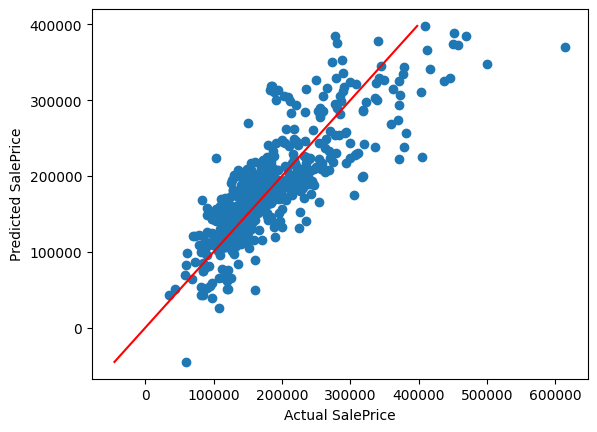

In [223]:
import matplotlib.pyplot as plt

# See how well our model performs on our test data
y_pred = myfit2.predict(X_test)
plt.scatter(y_test, y_pred)
plt.plot([min(y_pred), max(y_pred)],[min(y_pred), max(y_pred)], c='red')
plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice') ;

In [213]:
list(zip(y_test,y_pred))[:10]

[(247000, np.float64(188079.34153846634)),
 (135000, np.float64(172391.027784916)),
 (165000, np.float64(197368.3922939812)),
 (127500, np.float64(195032.75932597223)),
 (105000, np.float64(148664.7321123096)),
 (100000, np.float64(111354.67191284959)),
 (201800, np.float64(245453.4612587824)),
 (235128, np.float64(140186.57223903039)),
 (155000, np.float64(168582.6431792956)),
 (104000, np.float64(157199.07043449805))]

In [215]:
from sklearn.metrics import mean_squared_error

# Calculate root mean squared error on test data
rmse = mean_squared_error(y_test, y_pred)**0.5
print(f"RMSE: {rmse}")

RMSE: 45473.78014363083


In [218]:
from sklearn.model_selection import cross_val_score

results = cross_val_score(model, X, y, scoring='neg_root_mean_squared_error', cv = 10)
rmse = abs(results.mean())
print(f"CV RMSE: {rmse}")

CV RMSE: 44926.507011249465


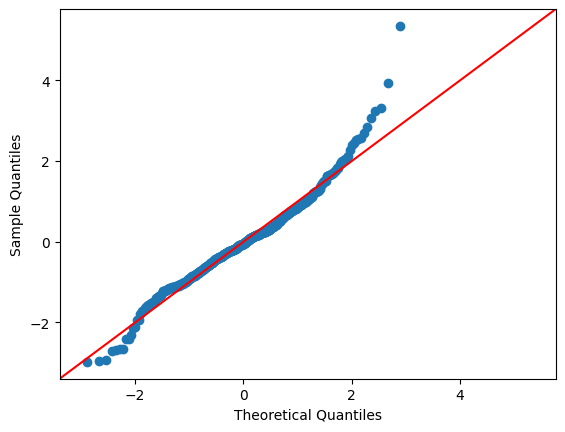

In [219]:
# QQ Plot - Residuals are normally distributed
res = y_test - y_pred
sm.qqplot(res, fit=True, line="45") ;

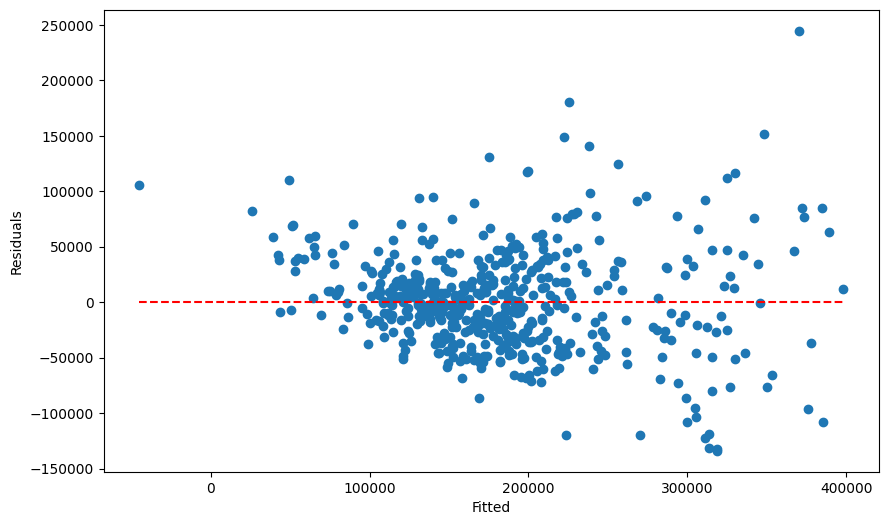

In [220]:
# Residuals vs Fitted (Predicted) Values - Constant variance
plt.figure(figsize = (10,6))
plt.scatter(y_pred, res)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.hlines(0, min(y_pred), max(y_pred), colors = 'red', linestyles = 'dashed') ;

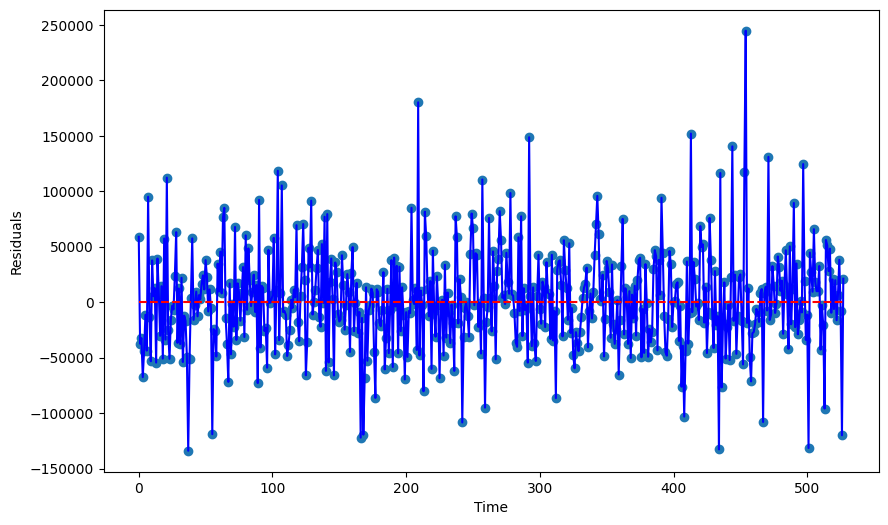

In [221]:
# Residuals vs Time - indepedence
plt.figure(figsize = (10,6))
plt.scatter(range(len(res)), res)
plt.plot(range(len(res)), res, 'b')
plt.xlabel("Time")
plt.ylabel("Residuals")
plt.hlines(0, min(range(len(res))), max(range(len(res))), colors = 'red', linestyles = 'dashed') ;

In [224]:
np.sqrt(np.mean(np.square((y_test - y_pred) / y_test))) * 100

np.float64(26.433485683624692)

**Conclusion:**
* The **RMSPE** is **26%** meaning that, on average, the predicted value deviates from the actual value 26% of the time.
* Outliers are clearly affecting the model performance: see the "predicted" v. "actual" plot.

# Future Development

* Removing outliers and transforming skewed distributions (including the target variable) using a logarithmic or similar transformation will improve model outcomes.